In [64]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

NUMBER_OF_SQUARES = 4
NUMBER_OF_GAMES = int(1e3)
START_POS_ALICE = 1
START_POS_BOB = NUMBER_OF_SQUARES - 2

np.set_printoptions(formatter={'float': '{: 0.2f}'.format}, linewidth=100)

In [65]:
# Softmax to perform Boltzmann exploration
def softmax(vector, temperature):
  exp_vector = np.exp(vector / temperature)
  return exp_vector / np.sum(exp_vector)

class Walker():
  def __init__(self, name, start_position, world_dimension, use_brain, learning_rate=0.5, discount_factor=1, softmax_temperature=1):
    self.name = name
    self.start_position = start_position
    self.position = start_position

    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

    self.world_dimension = world_dimension

    # Initialization as random walker
    self.q_table = np.ones((world_dimension, world_dimension, 3)) / 3

    self.learning_rate = learning_rate
    self.discount_factor = discount_factor

    self.softmax_temperature = softmax_temperature

    self.use_brain = use_brain

  def reset(self):
    self.position = self.start_position
    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

  def update_memory(self, my_position, other_position, my_move):
    self.memory['my_previous_position'] = my_position
    self.memory['my_previous_move'] = my_move
    self.memory['other_walker_previous_position'] = other_position

  def get_policy_tensor(self):
    probability_tensor = np.zeros((self.world_dimension, self.world_dimension, 3))
    for i in range(self.world_dimension):
      for j in range(self.world_dimension):
        probability_tensor[i, j] = softmax(self.q_table[i, j], self.softmax_temperature)
    return probability_tensor

  def choose_move(self, other_walker_position):
    if self.use_brain:
      # Policy
      probabilities = softmax(self.q_table[self.position, other_walker_position], self.softmax_temperature)
      move = np.random.choice([-1, 0, 1], p=probabilities)
    else:
      move = np.random.choice([-1, 0, 1])
    return move

  def check_if_move_is_possible(self, move):
    # Check if we end up under 0
    if self.position + move < 0:
      return False
    # Check if we end up over the world dimension
    elif self.position + move >= self.world_dimension:
      return False
    else:
      return True

  def move(self, other_position):
    move = self.choose_move(other_position)
    self.update_memory(self.position, other_position, move)
    if self.check_if_move_is_possible(move):
      self.position += move

  def update_brain(self, reward, other_position):
    if self.use_brain:
      old_q_value = self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1]
      new_q_value = reward + self.discount_factor * np.max(self.q_table[self.position, other_position])
      self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1] = \
        (1-self.learning_rate) * old_q_value + self.learning_rate * new_q_value


In [66]:
def check_same_position(walker_1, walker_2):
  if walker_1.position == walker_2.position:
    return True
  else:
    return False

def check_compenetration(walker_1, walker_2):
  if walker_1.memory['my_previous_position'] == walker_2.position and walker_2.memory['my_previous_position'] == walker_1.position:
    return True
  else:
    return False

def check_end_game(walker_1, walker_2):
  end_game = False
  compenetration = False
  if check_same_position(walker_1, walker_2):
    end_game = True
  elif check_compenetration(walker_1, walker_2):
    # Coin toss to choose the final position of the two walkers
    if np.random.rand() < 0.5:
      walker_1.position = walker_2.position
    else:
      walker_2.position = walker_1.position
    end_game = True
    compenetration = True
  else:
    end_game = False

  return end_game, compenetration

def calculate_reward(meeting_square, world_dimension):
  walker_1_reward = ((world_dimension - 1)/ 2) - meeting_square
  walker_2_reward = meeting_square - ((world_dimension - 1) / 2)
  return walker_1_reward, walker_2_reward


def play_one_game(walker_1, walker_2, world_dimension):
  # Reset the walkers
  walker_1.reset()
  walker_2.reset()
  moves = 0
  while True:
    walker_1.move(walker_2.position)
    walker_2.move(walker_1.position)
    moves += 1

    end_game, compenetration = check_end_game(walker_1, walker_2)

    if end_game:

      if walker_1.position != walker_2.position:
        raise Exception('The walkers are not in the same position at the end of the game')
      else:
        meeting_square = walker_1.position

      walker_1_reward, walker_2_reward = calculate_reward(
          meeting_square,
          world_dimension,
        )

      walker_1.update_brain(walker_1_reward, walker_2.position)
      walker_2.update_brain(walker_2_reward, walker_1.position)
      break
    else:
      walker_1.update_brain(0, walker_2.position)
      walker_2.update_brain(0, walker_1.position)

  return walker_1_reward, walker_2_reward, moves, meeting_square

Meeting square 0.0 -> Walker 1 (Alice) reward 1.5
Meeting square 1.0 -> Walker 1 (Alice) reward 0.5
Meeting square 2.0 -> Walker 1 (Alice) reward -0.5
Meeting square 3.0 -> Walker 1 (Alice) reward -1.5


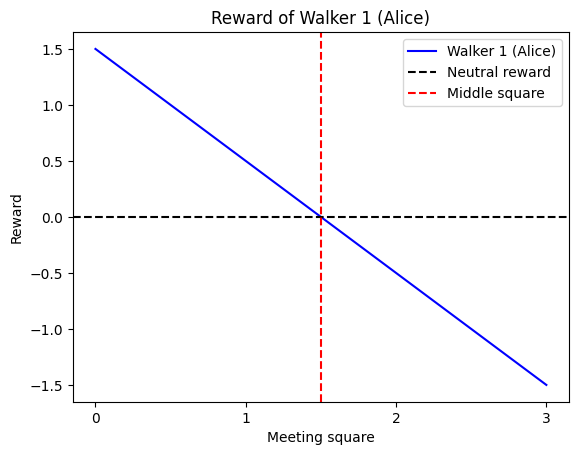

In [67]:
# Plot walker_1 (Alice) reward

meeting_squares =  np.linspace(0, NUMBER_OF_SQUARES-1, NUMBER_OF_SQUARES)
walker_1_rewards = []
for meeting_square in meeting_squares:
  walker_1_reward, _ = calculate_reward(meeting_square, NUMBER_OF_SQUARES)
  print(f'Meeting square {meeting_square} -> Walker 1 (Alice) reward {walker_1_reward}')
  walker_1_rewards.append(walker_1_reward)

plt.title('Reward of Walker 1 (Alice)')
plt.xlabel('Meeting square')
plt.ylabel('Reward')
plt.plot(meeting_squares, walker_1_rewards, label='Walker 1 (Alice)', color='blue')
plt.axhline(0, color='black', linestyle='--', label='Neutral reward')
plt.axvline((NUMBER_OF_SQUARES - 1) / 2, color='red', linestyle='--', label='Middle square')
plt.xticks(np.arange(0, NUMBER_OF_SQUARES, 1))
plt.legend()
plt.show()

In [68]:
def calculate_entropy_of_probability_tensor(probability_tensor):
  entropy = 0
  for i in range(probability_tensor.shape[0]):
    for j in range(probability_tensor.shape[1]):
      for k in range(probability_tensor.shape[2]):
        entropy -= probability_tensor[i, j, k] * np.log2(probability_tensor[i, j, k])

  maximum_possible_entropy = np.log2(probability_tensor.shape[2]) * probability_tensor.shape[0] * probability_tensor.shape[1]
  negentropy = maximum_possible_entropy - entropy

  entropy = round(entropy, 10)
  negentropy = round(negentropy, 10)

  return entropy, negentropy

In [69]:
# This initialization is crucial: Alice uses the brain and Bob doesn't!
alice = Walker(name='Alice', start_position=START_POS_ALICE, world_dimension=NUMBER_OF_SQUARES, use_brain=True)
bob = Walker(name='Bob', start_position=START_POS_BOB, world_dimension=NUMBER_OF_SQUARES, use_brain=False)

alice_rewards = []
bob_rewards = []
meeting_squares = []
alice_entropies = []
bob_entropies = []
alice_negentropies = []
bob_negentropies = []

for i in tqdm(range(NUMBER_OF_GAMES)):
  alice_reward, bob_reward, moves, meeting_square = play_one_game(
      alice,
      bob,
      NUMBER_OF_SQUARES
    )
  alice_rewards.append(alice_reward)
  bob_rewards.append(bob_reward)
  meeting_squares.append(meeting_square)

  alice_probability_tensor = alice.get_policy_tensor()
  bob_probability_tensor = bob.get_policy_tensor()

  alice_entropy, alice_negentropy = calculate_entropy_of_probability_tensor(alice_probability_tensor)
  bob_entropy, bob_negentropy = calculate_entropy_of_probability_tensor(bob_probability_tensor)

  alice_entropies.append(alice_entropy)
  bob_entropies.append(bob_entropy)
  alice_negentropies.append(alice_negentropy)
  bob_negentropies.append(bob_negentropy)

  0%|          | 0/1000 [00:00<?, ?it/s]

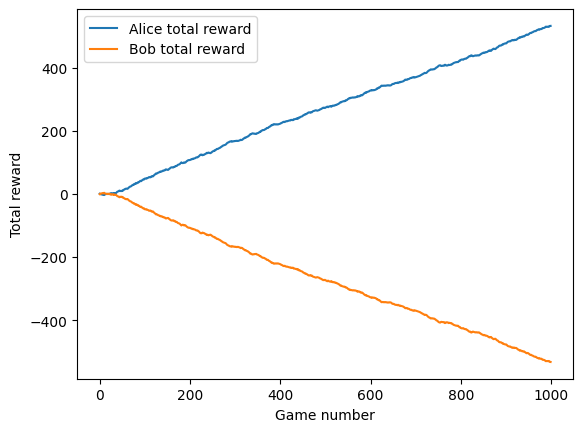

In [70]:
# Plot total reward vs game number

plt.plot(np.cumsum(alice_rewards), label='Alice total reward')
plt.plot(np.cumsum(bob_rewards), label='Bob total reward')
plt.xlabel('Game number')
plt.ylabel('Total reward')
plt.legend()
plt.show()

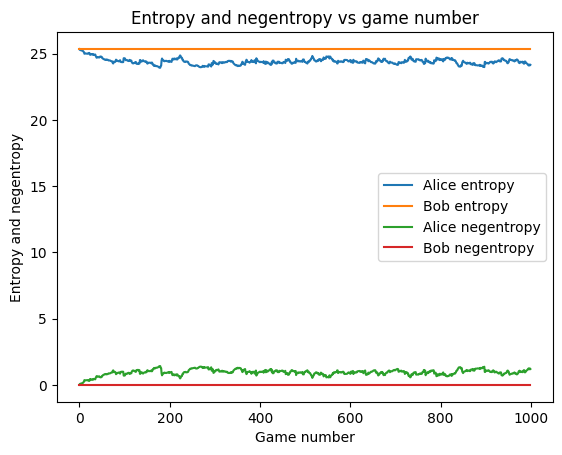

In [71]:
# Plot entropy and negentropy vs game number

plt.title('Entropy and negentropy vs game number')
plt.plot(alice_entropies, label='Alice entropy')
plt.plot(bob_entropies, label='Bob entropy')
plt.plot(alice_negentropies, label='Alice negentropy')
plt.plot(bob_negentropies, label='Bob negentropy')
plt.xlabel('Game number')
plt.ylabel('Entropy and negentropy')
plt.legend()
plt.show()

In [72]:
# Get sample random dynamic:

# Get experimental first encounter positions without brain (random walkers)

alice_random = Walker(name='Alice', start_position=0, world_dimension=NUMBER_OF_SQUARES, use_brain=False)
bob_random = Walker(name='Bob', start_position=NUMBER_OF_SQUARES-1, world_dimension=NUMBER_OF_SQUARES, use_brain=False)

random_meeting_squares = []

for i in tqdm(range(NUMBER_OF_GAMES), desc='Get random dynamic'):
  _, _, _, meeting_square = play_one_game(
      alice_random,
      bob_random,
      NUMBER_OF_SQUARES
    )
  random_meeting_squares.append(meeting_square)

Get random dynamic:   0%|          | 0/1000 [00:00<?, ?it/s]

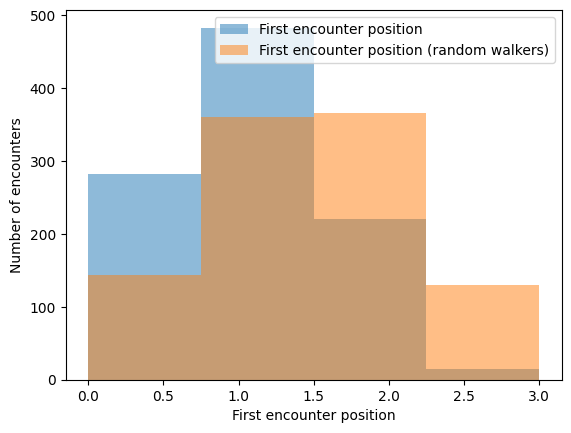

In [73]:
# Plot first encounter histograms

first_encounter_positions = meeting_squares
random_first_encounter_positions = random_meeting_squares

plt.hist(first_encounter_positions, bins=NUMBER_OF_SQUARES, label='First encounter position', alpha=0.5)
plt.hist(random_first_encounter_positions, bins=NUMBER_OF_SQUARES, label='First encounter position (random walkers)', alpha=0.5)
plt.xlabel('First encounter position')
plt.ylabel('Number of encounters')
plt.legend()

plt.show()


In [90]:
# Build matrix A

def convert_indices_to_global(i, j, i_prime, j_prime):
    '''
    This is crucial!
    (i, j) position and future position of the first walker
    (i_prime, j_prime) position and future position of the second walker
    The priming indicates the second walker!
    ATTENTION: the global indices work only if swapped for some reason!
    '''
    global_i = i * NUMBER_OF_SQUARES + i_prime
    global_j = j * NUMBER_OF_SQUARES + j_prime
    return global_i, global_j

def impose_reflective_boundary_conditions(probability_tensor):
  '''
  Transfers the probability mass from the sides to the stationary state.
  This is crucial since in the simulation the walkers are not allowed to go outside the world.
  And this limit is enforced by the environment!
  '''
  for i in range(NUMBER_OF_SQUARES):
    probability_tensor[0, i, 1] += probability_tensor[0, i, 0]
    probability_tensor[0, i, 0] = 0
    probability_tensor[NUMBER_OF_SQUARES-1, i, 1] += probability_tensor[NUMBER_OF_SQUARES-1, i, 2]
    probability_tensor[NUMBER_OF_SQUARES-1, i, 2] = 0

def build_matrix_A(walker_1_prob_tensor, walker_2_prob_tensor):
  '''
  Be careful! j (j') is the starting position!
  '''

  A = np.zeros((NUMBER_OF_SQUARES**2, NUMBER_OF_SQUARES**2))

  for i in range(NUMBER_OF_SQUARES):
    for j in range(NUMBER_OF_SQUARES):
      for i_prime in range(NUMBER_OF_SQUARES):
        for j_prime in range(NUMBER_OF_SQUARES):
          
          global_i, global_j = convert_indices_to_global(i, j, i_prime, j_prime)

          if np.abs(j-i) > 1 or np.abs(j_prime-i_prime) > 1:
            A[global_i, global_j] = 0

          elif j == i + 1 and j_prime == i_prime +1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i + 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i + 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i and j_prime == i_prime -1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i - 1 and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i - 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i - 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 2]
            
          else:
            raise Exception('This should not happen')

  return A

def add_absorbent_interactions(A, number_of_sites):
  # Insert interactions by replacing the columns with index: i + (i-1)*number_of_sites -1
  # with the identity column
  # (Notice the -1, it is there because the index start from 0 and not from 1)

  trap_indices_list = [i + (i-1)*number_of_sites - 1 for i in range(1, number_of_sites+1)]

  for index in trap_indices_list:
    A[:, index] = np.eye(number_of_sites**2)[:, index]

Alice probability tensor before boundaries:
Probabilities when I am in square 0 and the other walker is in square 0 : [ 0.33  0.33  0.33]
Probabilities when I am in square 0 and the other walker is in square 1 : [ 0.33  0.33  0.33]
Probabilities when I am in square 0 and the other walker is in square 2 : [ 0.33  0.33  0.33]
Probabilities when I am in square 0 and the other walker is in square 3 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 0 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 1 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 2 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 3 : [ 0.33  0.33  0.33]
Probabilities when I am in square 2 and the other walker is in square 0 : [ 0.33  0.33  0.33]
Probabilities when I am in square 2 and the other walker is in square 1 : [ 0.33  0.33  0.33]
Probabilities wh

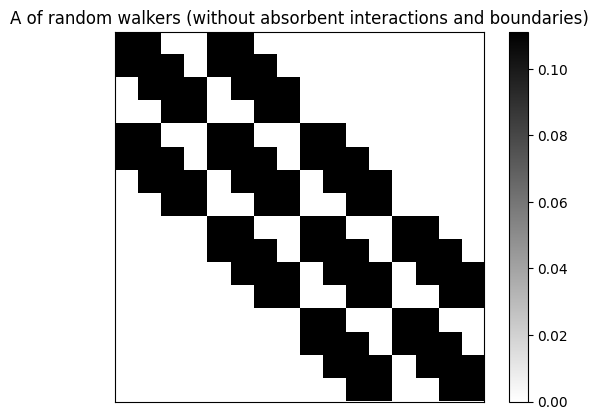

Alice probability tensor after boundaries:
Probabilities when I am in square 0 and the other walker is in square 0 : [ 0.00  0.67  0.33]
Probabilities when I am in square 0 and the other walker is in square 1 : [ 0.00  0.67  0.33]
Probabilities when I am in square 0 and the other walker is in square 2 : [ 0.00  0.67  0.33]
Probabilities when I am in square 0 and the other walker is in square 3 : [ 0.00  0.67  0.33]
Probabilities when I am in square 1 and the other walker is in square 0 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 1 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 2 : [ 0.33  0.33  0.33]
Probabilities when I am in square 1 and the other walker is in square 3 : [ 0.33  0.33  0.33]
Probabilities when I am in square 2 and the other walker is in square 0 : [ 0.33  0.33  0.33]
Probabilities when I am in square 2 and the other walker is in square 1 : [ 0.33  0.33  0.33]
Probabilities whe

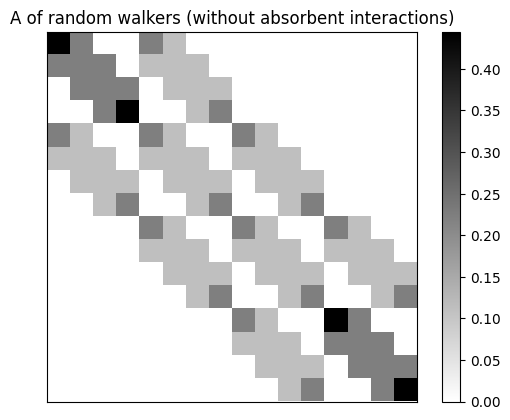

A matrix of random walkers after adding absorbent interactions:
[[ 1.00  0.22  0.00  0.00  0.22  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.22  0.22  0.00  0.11  0.00  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.22  0.22  0.22  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.22  0.44  0.00  0.00  0.11  0.22  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.11  0.00  0.00  0.22  0.00  0.00  0.00  0.22  0.11  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.11  0.11  0.00  0.11  1.00  0.11  0.00  0.11  0.11  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.11  0.11  0.11  0.00  0.00  0.11  0.11  0.00  0.11  0.00  0.11  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.11  0.22  0.00  0.00  0.11  0.22  0.00  0.00  0.00  0.22  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.22  0.00  0.00  0.00  0.22  0.11  0.00  0.00  0.22  0.11  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.11  0.00  0.11  

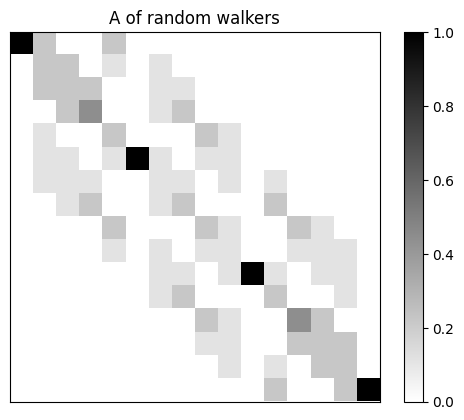

In [ ]:
# Calculate matrix A for random walkers and Alice with brain

# Random walkers
alice_random_probability_tensor = alice_random.get_policy_tensor()
bob_random_probability_tensor = bob_random.get_policy_tensor()

A_random_no_boundaries = build_matrix_A(alice_random_probability_tensor, bob_random_probability_tensor)

# Print A matrix
if NUMBER_OF_SQUARES <= 4:
    print('A matrix of random walkers before adding absorbent interactions and boundaries:')
    print(A_random_no_boundaries)

# Make plot

plt.imshow(A_random_no_boundaries, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of random walkers (without absorbent interactions and boundaries)')
plt.xticks([])
plt.yticks([])
plt.show()

# Imposing reflective boundary conditions
impose_reflective_boundary_conditions(alice_random_probability_tensor)
impose_reflective_boundary_conditions(bob_random_probability_tensor)

# Build A matrix

A_random = build_matrix_A(alice_random_probability_tensor, bob_random_probability_tensor)

# Print A matrix
if NUMBER_OF_SQUARES <= 4:
    print('A matrix of random walkers before adding absorbent interactions:')
    print(A_random)

# Make plot

plt.imshow(A_random, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of random walkers (without absorbent interactions)')
plt.xticks([])
plt.yticks([])
plt.show()

# Add absorbent interactions

add_absorbent_interactions(A_random, NUMBER_OF_SQUARES)

# Print A matrix

if NUMBER_OF_SQUARES <= 4:
    print('A matrix of random walkers after adding absorbent interactions:')
    print(A_random)

# Make plot

plt.imshow(A_random, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of random walkers')
plt.xticks([])
plt.yticks([])
plt.show()


Alice probability tensor before boundaries:
Probabilities when I am in square 0 and the other walker is in square 0 : [ 0.12  0.50  0.38]
Probabilities when I am in square 0 and the other walker is in square 1 : [ 0.12  0.50  0.38]
Probabilities when I am in square 0 and the other walker is in square 2 : [ 0.12  0.50  0.38]
Probabilities when I am in square 0 and the other walker is in square 3 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 0 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 1 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 2 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 3 : [ 0.12  0.50  0.38]
Probabilities when I am in square 2 and the other walker is in square 0 : [ 0.12  0.50  0.38]
Probabilities when I am in square 2 and the other walker is in square 1 : [ 0.12  0.50  0.38]
Probabilities wh

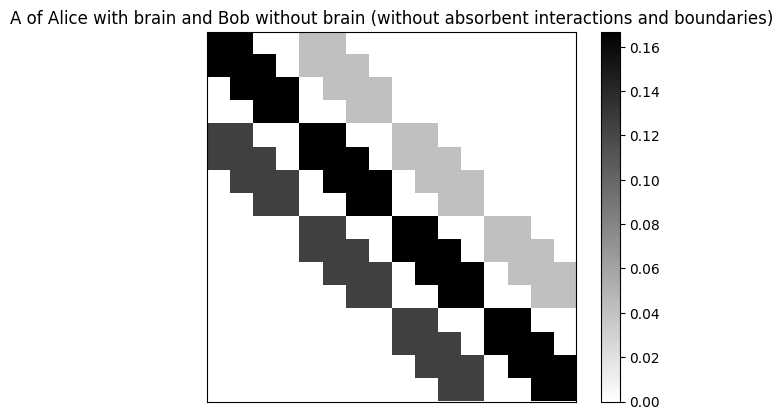

Alice probability tensor after boundaries:
Probabilities when I am in square 0 and the other walker is in square 0 : [ 0.00  0.62  0.38]
Probabilities when I am in square 0 and the other walker is in square 1 : [ 0.00  0.62  0.38]
Probabilities when I am in square 0 and the other walker is in square 2 : [ 0.00  0.62  0.38]
Probabilities when I am in square 0 and the other walker is in square 3 : [ 0.00  0.62  0.38]
Probabilities when I am in square 1 and the other walker is in square 0 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 1 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 2 : [ 0.12  0.50  0.38]
Probabilities when I am in square 1 and the other walker is in square 3 : [ 0.12  0.50  0.38]
Probabilities when I am in square 2 and the other walker is in square 0 : [ 0.12  0.50  0.38]
Probabilities when I am in square 2 and the other walker is in square 1 : [ 0.12  0.50  0.38]
Probabilities whe

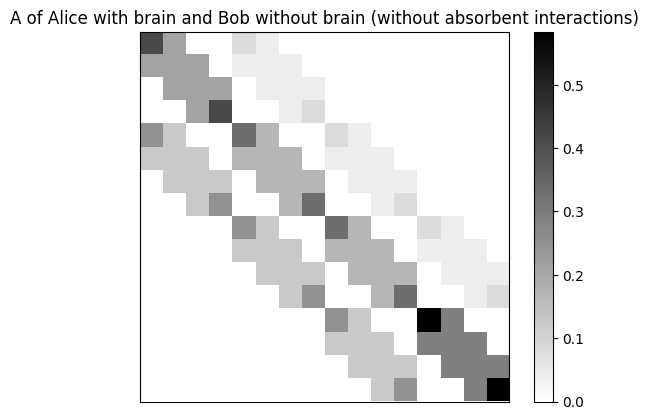

A matrix of Alice with brain and Bob without brain after adding absorbent interactions:
[[ 1.00  0.21  0.00  0.00  0.08  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.21  0.21  0.00  0.04  0.00  0.04  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.21  0.21  0.21  0.00  0.00  0.04  0.04  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.21  0.42  0.00  0.00  0.04  0.08  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.12  0.00  0.00  0.33  0.00  0.00  0.00  0.08  0.04  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.12  0.12  0.00  0.17  1.00  0.17  0.00  0.04  0.04  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.12  0.12  0.12  0.00  0.00  0.17  0.17  0.00  0.04  0.00  0.04  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.12  0.25  0.00  0.00  0.17  0.33  0.00  0.00  0.00  0.08  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.25  0.00  0.00  0.00  0.33  0.17  0.00  0.00  0.08  0.04  0.00  0.00]
 [ 0.00  0.00  0.00  

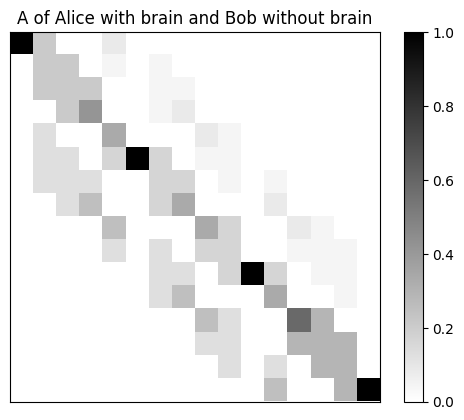

In [ ]:
# Make the same thing but for Alice with brain and Bob without brain

alice_probability_tensor_fake = np.zeros((NUMBER_OF_SQUARES, NUMBER_OF_SQUARES, 3))
for i in range(NUMBER_OF_SQUARES):
  for j in range(NUMBER_OF_SQUARES):
    alice_probability_tensor_fake[i, j, 0] = 1/8
    alice_probability_tensor_fake[i, j, 1] = 1/2
    alice_probability_tensor_fake[i, j, 2] = 3/8

#alice_probability_tensor = alice.get_policy_tensor()
bob_probability_tensor = bob.get_policy_tensor()

A_no_boundaries = build_matrix_A(alice_probability_tensor_fake, bob_probability_tensor)

# Print A matrix
if NUMBER_OF_SQUARES <= 4:
    print('A matrix of Alice with brain and Bob without brain before adding absorbent interactions and boundaries:')
    print(A_no_boundaries)

# Make plot
plt.imshow(A_no_boundaries, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of Alice with brain and Bob without brain (without absorbent interactions and boundaries)')
plt.xticks([])
plt.yticks([])
plt.show()

# Imposing reflective boundary conditions

impose_reflective_boundary_conditions(alice_probability_tensor_fake)
impose_reflective_boundary_conditions(bob_probability_tensor)

# Build A matrix

A = build_matrix_A(alice_probability_tensor_fake, bob_probability_tensor)

# Print A matrix
if NUMBER_OF_SQUARES <= 4:
    print('A matrix of Alice with brain and Bob without brain before adding absorbent interactions:')
    print(A)

# Make plot
plt.imshow(A, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of Alice with brain and Bob without brain (without absorbent interactions)')
plt.xticks([])
plt.yticks([])
plt.show()

# Add absorbent interactions

add_absorbent_interactions(A, NUMBER_OF_SQUARES)

# Print A matrix
if NUMBER_OF_SQUARES <= 4:
    print('A matrix of Alice with brain and Bob without brain after adding absorbent interactions:')
    print(A)

# Make plot
plt.imshow(A, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of Alice with brain and Bob without brain')
plt.xticks([])
plt.yticks([])
plt.show()


In [93]:
# Get theoretical curves for both cases

def get_cursive_Pts(current_A, P0, number_of_sites, free_probability_treshhold_for_theory_calc):
    '''
    Calculate time evolution, and so the capture probability on sites (cursive P)
    '''

    trap_indices_list = [i + (i-1)*number_of_sites - 1 for i in range(1, number_of_sites+1)]

    Pt = np.matmul(current_A, P0)

    delta_iterations_for_check = 100
    iterations = 0

    while True:

        Pt = np.dot(current_A, Pt)

        Cursive_Pts = []

        for index in trap_indices_list:
            Cursive_Pts.append(Pt[index])

        # Check probability mass trapped

        trapped_prob_mass = sum(Cursive_Pts)

        if iterations % delta_iterations_for_check == 0:
            print(f'Trapped probability mass at iteration {iterations}: {trapped_prob_mass}')

        if 1 - trapped_prob_mass < free_probability_treshhold_for_theory_calc:
            break
        else:
            iterations += 1

    return Cursive_Pts

# Specifing the start distribution

P0_Alice = np.zeros(NUMBER_OF_SQUARES)
P0_Alice[START_POS_ALICE] = 1

P0_Bob = np.zeros(NUMBER_OF_SQUARES)
P0_Bob[START_POS_BOB] = 1

# General P0

P0 = np.kron(P0_Alice, P0_Bob)

Trapped probability mass at iteration 0: 0.37037037037037046
Trapped probability mass at iteration 0: 0.45833333333333337
Trapped probability mass at iteration 100: 0.9999903132797834


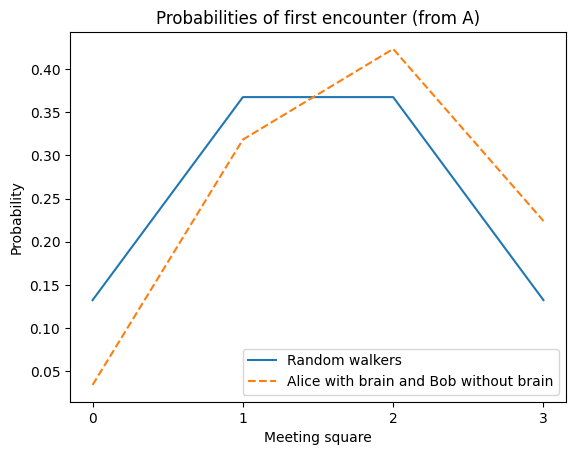

In [95]:
# Plot cursive Pts for the complete no brain case

cursive_Pts_random = get_cursive_Pts(A_random, P0, NUMBER_OF_SQUARES, 10e-6)
cursive_Pts = get_cursive_Pts(A, P0, NUMBER_OF_SQUARES, 10e-6)

plt.title('Probabilities of first encounter (from A)')
plt.plot(cursive_Pts_random, label='Random walkers')
plt.plot(cursive_Pts, label='Alice with brain and Bob without brain', linestyle='--')
plt.xlabel('Meeting square')
plt.ylabel('Probability')
plt.legend()
plt.xticks(np.arange(0, NUMBER_OF_SQUARES, 1))
plt.show()

